In [2]:
import pandas as pd
import glob
import string
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from nltk.corpus import wordnet
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline, DataCollatorWithPadding
from transformers_interpret import SequenceClassificationExplainer
from datasets import Dataset,load_dataset
from sklearn.preprocessing import LabelEncoder
import torch
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from torch import nn
from captum.attr import LayerIntegratedGradients
import random
from evaluate import load

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Combining separte files into one

In [14]:
folder_path = "CSV files/*.csv"
all_files = glob.glob(folder_path)
df_list = [pd.read_csv(filename) for filename in all_files]
df = pd.concat(df_list, ignore_index=True)

In [15]:
df.head()

,,Time,Time.1,Place,Place.1,Place.2,Place.3,Place.4,Place.5,Place.6,...,Events.4,Events.5,Assessments,Assessments.1,Report 1,Report 1.1,Report 2,Report 2.1,Report 1.2,Unnamed: 125
0,ACN,Date,Local Time Of Day,Locale Reference,State Reference,Relative Position.Angle.Radial,Relative Position.Distance.Nautical Miles,Altitude.AGL.Single Value,Altitude.MSL.Single Value,Latitude / Longitude (UAS),...,When Detected,Result,Contributing Factors / Situations,Primary Problem,Narrative,Callback,Narrative,Callback,Synopsis,NaN
1,2290712,202510,1801-2400,ZZZ.Airport,US,NaN,NaN,NaN,6000,NaN,...,In-flight,Air Traffic Control Issued New Clearance; Air ...,Weather; Procedure; Human Factors; Airspace St...,Human Factors,I issued Aircraft X a descent to 065 as he was...,NaN,NaN,NaN,A TRACON Controller reported an aircraft on ap...,NaN
2,2290714,202510,1801-2400,ZZZ.ARTCC,US,NaN,NaN,NaN,10200,NaN,...,In-flight,Air Traffic Control Provided Assistance; Air T...,Airspace Structure; Chart Or Publication; Weather,Weather,Aircraft X is a C206 that called for a pop-up ...,NaN,NaN,NaN,A Center Controller reported an aircraft exper...,NaN
3,2290822,202510,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Aircraft In Service At Gate,Flight Crew Regained Aircraft Control,Aircraft; Human Factors,Human Factors,Aircraft tow was being hooked up with strap. b...,NaN,NaN,NaN,Ground personnel reported that the aircraft br...,NaN
4,2290835,202510,0601-1200,VDF.Airport,FL,NaN,NaN,NaN,NaN,NaN,...,In-flight,Flight Crew Took Evasive Action,Human Factors; Airspace Structure,Airspace Structure,Coming into VDF we canceled IFR and began a tu...,NaN,NaN,NaN,Air taxi First Officer reported a traffic conf...,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Columns: 126 entries,   to Unnamed: 125
dtypes: float64(1), object(125)
memory usage: 29.9+ MB


In [17]:
df_1 = df.copy()

In [18]:
df_1 = df_1[['Assessments.1','Report 1']]

In [19]:
df_1.head()

,Assessments.1,Report 1
0,Primary Problem,Narrative
1,Human Factors,I issued Aircraft X a descent to 065 as he was...
2,Weather,Aircraft X is a C206 that called for a pop-up ...
3,Human Factors,Aircraft tow was being hooked up with strap. b...
4,Airspace Structure,Coming into VDF we canceled IFR and began a tu...


In [20]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Assessments.1  31064 non-null  object
 1   Report 1       31138 non-null  object
dtypes: object(2)
memory usage: 486.7+ KB


Checking for missing values

In [21]:
df_1.isnull().sum()/len(df_1) * 100

,0
Assessments.1,0.247262
Report 1,0.009634


Dropping Missing Values

In [22]:
df_1.dropna(inplace = True)

In [23]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31064 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Assessments.1  31064 non-null  object
 1   Report 1       31064 non-null  object
dtypes: object(2)
memory usage: 728.1+ KB


In [24]:
df_1.isnull().sum()/len(df_1) * 100

,0
Assessments.1,0.0
Report 1,0.0


Changing column name to first row

In [25]:
df_1.columns = df_1.iloc[0]
df_1 = df_1.drop(df.index[0])
df_1 = df_1.reset_index(drop=True)

In [26]:
df_1.head()

,Primary Problem,Narrative
0,Human Factors,I issued Aircraft X a descent to 065 as he was...
1,Weather,Aircraft X is a C206 that called for a pop-up ...
2,Human Factors,Aircraft tow was being hooked up with strap. b...
3,Airspace Structure,Coming into VDF we canceled IFR and began a tu...
4,Ambiguous,After landing in ZZZ at night; we received ATC...


In [27]:
df_1['Primary Problem'].value_counts()

,count
Primary Problem,
Human Factors,10823
Aircraft,9802
Procedure,2913
Ambiguous,2490
Weather,1059
Environment - Non Weather Related,930
Airport,786
Chart Or Publication,447
Airspace Structure,411


In [28]:
df_1.drop(df_1[df_1['Primary Problem'] == 'Primary Problem'].index, inplace=True)

In [29]:
df_1['Primary Problem'] = df_1['Primary Problem'].str.split(';').str[0].str.strip()
df_1['Primary Problem'].value_counts()

,count
Primary Problem,
Human Factors,10829
Aircraft,9804
Procedure,2916
Ambiguous,2491
Weather,1061
Environment - Non Weather Related,930
Airport,786
Chart Or Publication,448
ATC Equipment / Nav Facility / Buildings,411


In [30]:
df_2 = df_1.copy()

[]

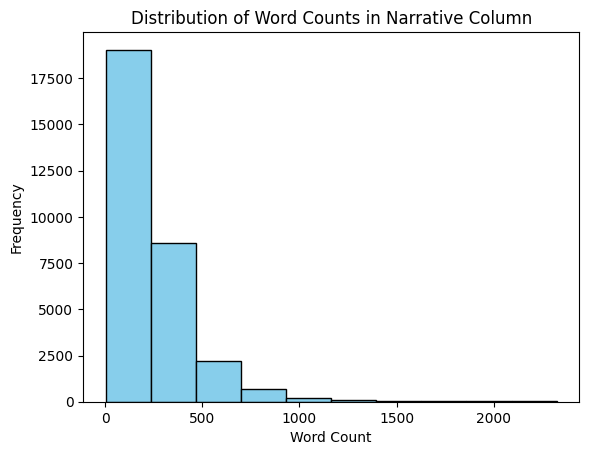

In [31]:
df_2['word_count'] = df_2['Narrative'].str.split().str.len()

fig, ax = plt.subplots()
ax.hist(df_2['word_count'], bins=10, edgecolor='black', color='skyblue')
ax.set_title('Distribution of Word Counts in Narrative Column')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')

plt.plot()

Making narrative lowercase

In [ ]:
df_1['Narrative'] = df_1['Narrative'].str.lower()
df_1['Narrative'][0]

"i issued aircraft x a descent to 065 as he was inbound from the east requesting the tacan xx approach at zzz. aircraft x read back; 'descending to 065'.  after this a commercial jet from the south was checking on; and subsequently asking questions about how busy i was; and if i needed to give him a short cut for the sequence he could take that. the pilot was trying to be helpful but was interrupting my scan. i was responding to his questions and continuing my scan when i noticed aircraft x at 060 in the 065 mva east of city x. i issued a safety alert to aircraft x and he advised he was climbing back to 065. as aircraft x was joining the tacan inbound to zzz he advised me that he had been struck by lightening.  i asked if he required any assistance and he said no. i believe maybe the lightening strike and him descending below the mva were related but i'm not sure. there was precipitation in the airspace but there was none depicted within around 10-15 miles of aircraft x so none was iss

In [ ]:
punc = string.punctuation

Removing punctuation

In [ ]:
def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_punc)

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash during descent into mmmx on the enaga3a arrival between fl200 to 17000ft agl aircraft was taken ots out of service  cause workload the desk has all of the zzzmex turns in addition two zzzmga turns zzzxpl and zzz1gua all those segments are at max payload and weight restricted based on max structural landing weight which requires additional coordination with the captain and load planning popocatepetl was erupting and creating additional work modifying arrival and departure routes for ash avoidance there were also two flight segments with extensive maintenance delays this led to task saturation which created some loss of situational awareness  suggestions i was task saturated with no time to send a help message this was due to desk being overloaded with too many segments that require extra time due to weight restrictions and difficult airports on a routine day without weather or maintenance issues it still a hefty workload previous help messages sent

Removing Stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopword = stopwords.words('english')
def remove_stopwords(text):
    new_text = []

    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_stopwords)

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash  descent  mmmx   enaga3a arrival  fl200  17000ft agl aircraft  taken ots   service cause workload  desk     zzzmex turns  addition two zzzmga turns zzzxpl  zzz1gua   segments   max payload  weight restricted based  max structural landing weight  requires additional coordination   captain  load planning popocatepetl  erupting  creating additional work modifying arrival  departure routes  ash avoidance   also two flight segments  extensive maintenance delays  led  task saturation  created  loss  situational awareness suggestions   task saturated   time  send  help message   due  desk  overloaded   many segments  require extra time due  weight restrictions  difficult airports   routine day without weather  maintenance issues  still  hefty workload previous help messages sent   division   uneven responses workload issues   division   continuous issue'

Dealing with excessive whitespaces

In [ ]:
df_1['Narrative'] = df_1['Narrative'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash descent mmmx enaga3a arrival fl200 17000ft agl aircraft taken ots service cause workload desk zzzmex turns addition two zzzmga turns zzzxpl zzz1gua segments max payload weight restricted based max structural landing weight requires additional coordination captain load planning popocatepetl erupting creating additional work modifying arrival departure routes ash avoidance also two flight segments extensive maintenance delays led task saturation created loss situational awareness suggestions task saturated time send help message due desk overloaded many segments require extra time due weight restrictions difficult airports routine day without weather maintenance issues still hefty workload previous help messages sent division uneven responses workload issues division continuous issue'

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Tokenization

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(word_tokenize)

In [ ]:
df_1['Narrative'][0]

['flight',
 'encountered',
 'light',
 'volcanic',
 'ash',
 'descent',
 'mmmx',
 'enaga3a',
 'arrival',
 'fl200',
 '17000ft',
 'agl',
 'aircraft',
 'taken',
 'ots',
 'service',
 'cause',
 'workload',
 'desk',
 'zzzmex',
 'turns',
 'addition',
 'two',
 'zzzmga',
 'turns',
 'zzzxpl',
 'zzz1gua',
 'segments',
 'max',
 'payload',
 'weight',
 'restricted',
 'based',
 'max',
 'structural',
 'landing',
 'weight',
 'requires',
 'additional',
 'coordination',
 'captain',
 'load',
 'planning',
 'popocatepetl',
 'erupting',
 'creating',
 'additional',
 'work',
 'modifying',
 'arrival',
 'departure',
 'routes',
 'ash',
 'avoidance',
 'also',
 'two',
 'flight',
 'segments',
 'extensive',
 'maintenance',
 'delays',
 'led',
 'task',
 'saturation',
 'created',
 'loss',
 'situational',
 'awareness',
 'suggestions',
 'task',
 'saturated',
 'time',
 'send',
 'help',
 'message',
 'due',
 'desk',
 'overloaded',
 'many',
 'segments',
 'require',
 'extra',
 'time',
 'due',
 'weight',
 'restrictions',
 'diffic

Lemmitization

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def lemmatize_sentence(sentence_list):
    tagged = nltk.pos_tag(sentence_list)

    lemmatized_output = []
    for word, tag in tagged:
        wn_tag = tag[0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        pos = tag_dict.get(wn_tag, wordnet.NOUN)

        lemmatized_output.append(lemmatizer.lemmatize(word, pos))

    return lemmatized_output

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(lemmatize_sentence)

In [ ]:
df_1['Narrative'][0]

['flight',
 'encounter',
 'light',
 'volcanic',
 'ash',
 'descent',
 'mmmx',
 'enaga3a',
 'arrival',
 'fl200',
 '17000ft',
 'agl',
 'aircraft',
 'take',
 'ots',
 'service',
 'cause',
 'workload',
 'desk',
 'zzzmex',
 'turn',
 'addition',
 'two',
 'zzzmga',
 'turn',
 'zzzxpl',
 'zzz1gua',
 'segment',
 'max',
 'payload',
 'weight',
 'restrict',
 'base',
 'max',
 'structural',
 'landing',
 'weight',
 'require',
 'additional',
 'coordination',
 'captain',
 'load',
 'plan',
 'popocatepetl',
 'erupt',
 'create',
 'additional',
 'work',
 'modify',
 'arrival',
 'departure',
 'rout',
 'ash',
 'avoidance',
 'also',
 'two',
 'flight',
 'segment',
 'extensive',
 'maintenance',
 'delay',
 'lead',
 'task',
 'saturation',
 'create',
 'loss',
 'situational',
 'awareness',
 'suggestion',
 'task',
 'saturate',
 'time',
 'send',
 'help',
 'message',
 'due',
 'desk',
 'overload',
 'many',
 'segment',
 'require',
 'extra',
 'time',
 'due',
 'weight',
 'restriction',
 'difficult',
 'airport',
 'routine',
 '

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

Train test split

In [ ]:
X = df_1['Narrative'].copy()
y = df_1['Primary Problem'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)

Random Forest Model

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(class_weight = 'balanced'))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', RandomForestClassifier(class_weight='balanced'))])

In [ ]:
test_pred_rf = pipeline.predict(X_test)

In [ ]:
train_pred_rf = pipeline.predict(X_train)

In [ ]:
print(classification_report(y_test, test_pred_rf))

                                              precision    recall  f1-score   support

    ATC Equipment / Nav Facility / Buildings       0.00      0.00      0.00        84
                                    Aircraft       0.76      0.86      0.81      2004
                                     Airport       1.00      0.03      0.05       157
                          Airspace Structure       0.00      0.00      0.00        83
                                   Ambiguous       0.67      0.03      0.06       536
                        Chart Or Publication       0.88      0.09      0.16        81
                              Company Policy       0.00      0.00      0.00        85
           Environment - Non Weather Related       0.33      0.01      0.03       154
                         Equipment / Tooling       0.00      0.00      0.00        21
                               Human Factors       0.50      0.90      0.64      2120
Incorrect / Not Installed / Unavailable Part       1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


BERT, ROBERTA, AEROBERT

In [32]:
df_subset = df_2[['Narrative','Primary Problem']].copy()

In [33]:
df_subset['Narrative'] = df_subset['Narrative'].str.lower().str.strip()

In [34]:
label_encoder = LabelEncoder()
df_subset['labels'] = label_encoder.fit_transform(df_subset['Primary Problem'])
num_labels = len(label_encoder.classes_)

In [ ]:
df_subset.head()

,Narrative,Primary Problem,labels
0,i issued aircraft x a descent to 065 as he was...,Human Factors,9
1,aircraft x is a c206 that called for a pop-up ...,Weather,17
2,aircraft tow was being hooked up with strap. b...,Human Factors,9
3,coming into vdf we canceled ifr and began a tu...,Airspace Structure,3
4,after landing in zzz at night; we received atc...,Ambiguous,4


In [ ]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31055 entries, 0 to 31062
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Narrative        31055 non-null  object
 1   Primary Problem  31055 non-null  object
 2   labels           31055 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [ ]:
df_subset['Primary Problem'] = df_subset['Primary Problem'].astype(str)
df_subset['Narrative'] = df_subset['Narrative'].astype(str)
train, val = train_test_split(df_subset, test_size=0.2, random_state=42, stratify=df_subset['labels'])

In [ ]:
model_name = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
model_name = "FacebookAI/roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
model_name = "NASA-AIML/MIKA_SafeAeroBERT"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
#data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

In [ ]:
def tokenize_function(data):
    return bert_tokenizer(data['Narrative'], padding="max_length", truncation=True, max_length=512)

In [ ]:
train.head()

,Narrative,Primary Problem,labels
12075,after takeoff cabin pressure vsi (vertical spe...,Aircraft,1
19452,we flew a show for a client on day 0 at locati...,Ambiguous,4
16419,i recently was checked out in a da20-c1 aircra...,Aircraft,1
7982,while flying flight zzz - zzz1 the gear did no...,Aircraft,1
919,on day 0; at approximately xa:30; i; remote pi...,Ambiguous,4


In [ ]:
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24844 entries, 0 to 24843
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Narrative        24844 non-null  object
 1   Primary Problem  24844 non-null  object
 2   labels           24844 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 582.4+ KB


In [ ]:
train_dataset = Dataset.from_dict(train.to_dict(orient='list'))
val_dataset = Dataset.from_dict(val.to_dict(orient='list'))

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/24844 [00:00<?, ? examples/s]

Map:   0%|          | 0/6211 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels=num_labels,
                                                           hidden_dropout_prob=0.3,
                                                           attention_probs_dropout_prob=0.3)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: NASA-AIML/MIKA_SafeAeroBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those para

In [ ]:
df_subset['labels'].value_counts()

,count
labels,
9,10829
1,9804
14,2916
4,2491
17,1061
7,930
2,786
5,448
0,411


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df_subset['Primary Problem']), y=df_subset['Primary Problem']
)

In [ ]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
class WeightedTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Overrides the default loss computation to use weighted cross-entropy."""
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")


        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
def compute_metrics(eval_pred):
    f1_metric = load("f1")
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    return f1_metric.compute(predictions=preds, references=labels, average="macro")

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    weight_decay=0.1,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model = 'f1',
    load_best_model_at_end=True,
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4

)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,


#     fp16=torch.cuda.is_available(),
#     dataloader_num_workers=4,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=50,
#     report_to="none",
# )

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch,Training Loss,Validation Loss,F1
1,2.058638,1.837138,0.237631
2,2.063550,1.651685,0.286194
3,1.496542,1.600832,0.292995


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4659, training_loss=1.9007538303998337, metrics={'train_runtime': 2191.0438, 'train_samples_per_second': 34.017, 'train_steps_per_second': 2.126, 'total_flos': 1.9613010330279936e+16, 'train_loss': 1.9007538303998337, 'epoch': 3.0})

In [ ]:
model.save_pretrained("./saved_aerobert_model_3")
bert_tokenizer.save_pretrained("./saved_aerobert_model_3")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_aerobert_model_3/tokenizer_config.json',
 './saved_aerobert_model_3/tokenizer.json')

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("./saved_bert_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_bert_model")

OSError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './saved_aerobert_model'.

Testing

In [4]:
test_df = pd.read_csv('ASRS_2026(Jan-Jun).csv')

In [5]:
test_df_1 = test_df.copy()

In [6]:
test_df_1 = test_df_1[['Assessments.1','Report 1']]

In [7]:
test_df_1.dropna(inplace = True)

In [8]:
test_df_1.columns = test_df_1.iloc[0]
test_df_1 = test_df_1.drop(test_df_1.index[0])
test_df_1 = test_df_1.reset_index(drop=True)

In [9]:
test_df_1.tail()

,Primary Problem,Narrative
1226,Human Factors,I flew through a temporary UAS operations area...
1227,Ambiguous,Deviation from ATC clearance due to weather de...
1228,Human Factors,Began the shift with a weather brief regarding...
1229,Ambiguous,The approach was going well; the pilot flying ...
1230,Aircraft,In stable cruise flight; imc; negative ice;lig...


In [10]:
test_df_1['Primary Problem'] = test_df_1['Primary Problem'].str.split(';').str[0].str.strip()
test_df_1['Primary Problem'].value_counts()

,count
Primary Problem,
Human Factors,414
Aircraft,397
Ambiguous,83
Weather,77
Procedure,72
Airport,51
Environment - Non Weather Related,41
ATC Equipment / Nav Facility / Buildings,33
Airspace Structure,29


In [11]:
test_df_2 = test_df_1[['Narrative']].copy()

In [12]:
test_df_2['Narrative'] = test_df_2['Narrative'].str.lower()

In [35]:
test_df_1['labels'] = label_encoder.transform(test_df_1['Primary Problem'])

In [36]:
test_df_1['labels'].value_counts()

,count
labels,
9,414
1,397
4,83
17,77
14,72
2,51
7,41
0,33
3,29


In [37]:
model_path = "saved_aerobert_model_2"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.3, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
predictions = classifier(test_df_2['Narrative'].tolist(), batch_size=4, truncation=True)
test_df_2['Predicted_label'] = [pred['label'] for pred in predictions]

In [39]:
test_df_2.head()

,Narrative,Predicted_label
0,on downwind at 3;000 feet for runway 28l we we...,LABEL_5
1,at mdt; deicing operations were highly disorga...,LABEL_2
2,we put in the route at the gate with runway 36...,LABEL_0
3,aircraft x was requesting a vor-a approach to ...,LABEL_3
4,i was working 4 aircraft into sdm (3 jets and ...,LABEL_3


In [40]:
test_df_2['Predicted_label'] = test_df_2['Predicted_label'].str.replace('LABEL_', '', regex=False).astype(int)

In [41]:
test_df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Narrative        1231 non-null   object
 1   Predicted_label  1231 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 19.4+ KB


In [42]:
test_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Primary Problem  1231 non-null   object
 1   Narrative        1231 non-null   object
 2   labels           1231 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 29.0+ KB


In [43]:
test_df_2['labels'] = test_df_1['labels']

In [44]:
test_df_2.labels.value_counts()

,count
labels,
9,414
1,397
4,83
17,77
14,72
2,51
7,41
0,33
3,29


In [45]:
y_true = test_df_2['labels']
y_pred = test_df_2['Predicted_label']
report = classification_report(y_true, y_pred)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.73      0.59        33
           1       0.85      0.90      0.88       397
           2       0.45      0.65      0.53        51
           3       0.30      0.38      0.33        29
           4       0.22      0.36      0.27        83
           5       0.29      0.69      0.41        13
           6       0.00      0.00      0.00         3
           7       0.50      0.32      0.39        41
           8       0.00      0.00      0.00         1
           9       0.75      0.34      0.47       414
          10       0.10      0.50      0.17         2
          11       0.00      0.00      0.00         1
          12       0.07      1.00      0.13         1
          13       0.00      0.00      0.00         1
          14       0.22      0.22      0.22        72
          15       0.27      0.33      0.30        12
          16       0.00      0.00      0.00         0
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [46]:
test_df_3 = test_df_2.copy()

In [48]:
label_mapping = {
  9:'Human Factors',
  1:'Aircraft',
  4:'Ambigous',
  17:'Weather',
  14:'Procedure',
  2:'Airport',
  7:'Environment - Non Weather Related',
  0:'ATC Equipment / Nav Facility / Buildings',
  3:'Airspace Structure',
  5:'Chart Or Publication',
  15:'Software and Automation',
  6:'Company Policy',
  10:'Incorrect / Not Installed / Unavailable Part',
  13:	'Manuals',
  8: 'Equipment / Tooling',
  11:'Logbook Entry',
  12:	'MEL',
  16: 'Staffing'
}

In [49]:
test_df_2['Predicted'] = test_df_2['Predicted_label'].map(label_mapping)
test_df_2['Actual'] = test_df_2['labels'].map(label_mapping)

In [50]:
test_df_2.drop(columns = ['labels'],inplace = True)

In [51]:
test_df_2.drop(columns = ['Predicted_label'],inplace = True)

In [52]:
test_df_2.tail()

,Narrative,Predicted,Actual
1226,i flew through a temporary uas operations area...,Ambigous,Human Factors
1227,deviation from atc clearance due to weather de...,Weather,Ambigous
1228,began the shift with a weather brief regarding...,Weather,Human Factors
1229,the approach was going well; the pilot flying ...,Aircraft,Ambigous
1230,in stable cruise flight; imc; negative ice;lig...,Aircraft,Aircraft


In [ ]:
problem = input('Choose a problem to analyse: ')
mask = test_df_2['Actual'] == problem
filtered_df = test_df_2[mask]
filtered_df

Choose a problem to analyse: MEL


,Narrative,Predicted,Actual
1137,we performed a gate call for the aircraft rela...,MEL,MEL


Explainablity

In [61]:
def predict_forward_func(input_ids, attention_mask=None):
    output = model(input_ids=input_ids, attention_mask=attention_mask)
    return output.logits

In [62]:
model = AutoModelForSequenceClassification.from_pretrained("/content/saved_aerobert_model_2")
tokenizer = AutoTokenizer.from_pretrained("/content/saved_aerobert_model_2")
model.to(device)
model.eval()

embedding_layer = model.bert.embeddings

lig = LayerIntegratedGradients(model, embedding_layer)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [63]:
lig = LayerIntegratedGradients(predict_forward_func, model.bert.embeddings)

In [ ]:
text = "During the initial climb out of JFK International Airport, the flight crew noted a sudden, abnormal vibration accompanied by a rapid rise in Exhaust Gas Temperature (EGT) on the No. 2 (right) engine."
inputs = tokenizer(text, return_tensors="pt")

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

baseline_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
ref_input_ids = torch.full_like(input_ids, baseline_token_id)

outputs = model(input_ids, attention_mask=attention_mask)
predicted_class_idx = torch.argmax(outputs.logits, dim=1).item()

In [ ]:
attributions, delta = lig.attribute(
    inputs=input_ids,
    baselines=ref_input_ids,
    target=predicted_class_idx,
    additional_forward_args=(attention_mask,),
    n_steps=50,
    return_convergence_delta=True
)

token_attributions = attributions.sum(dim=-1).squeeze(0)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

for token, score in zip(tokens, token_attributions.tolist()):
    print(f"{token:<12} : {score:.4f}")

Confidence

In [ ]:
len(test_df_2)

1231

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("./saved_aerobert_model_2")
tokenizer = AutoTokenizer.from_pretrained("./saved_aerobert_model_2")

model.eval()
number = random.randint(0, len(test_df_2) - 1)

new_text = test_df_2['Narrative'][number]
inputs = tokenizer(new_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predictions = torch.softmax(logits, dim=-1)
predicted_class = torch.argmax(predictions, dim=-1)
scores = predictions.detach().numpy()
confidence = np.max(scores)

print(f"Predicted class: {label_mapping[predicted_class.item()]}")
print(f"Actual Class: {test_df_2['Actual'][number]}")
print(f"Confidence: {confidence * 100:.2f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicted class: Weather
Actual Class: Weather
Confidence: 97.76


Error Analysis

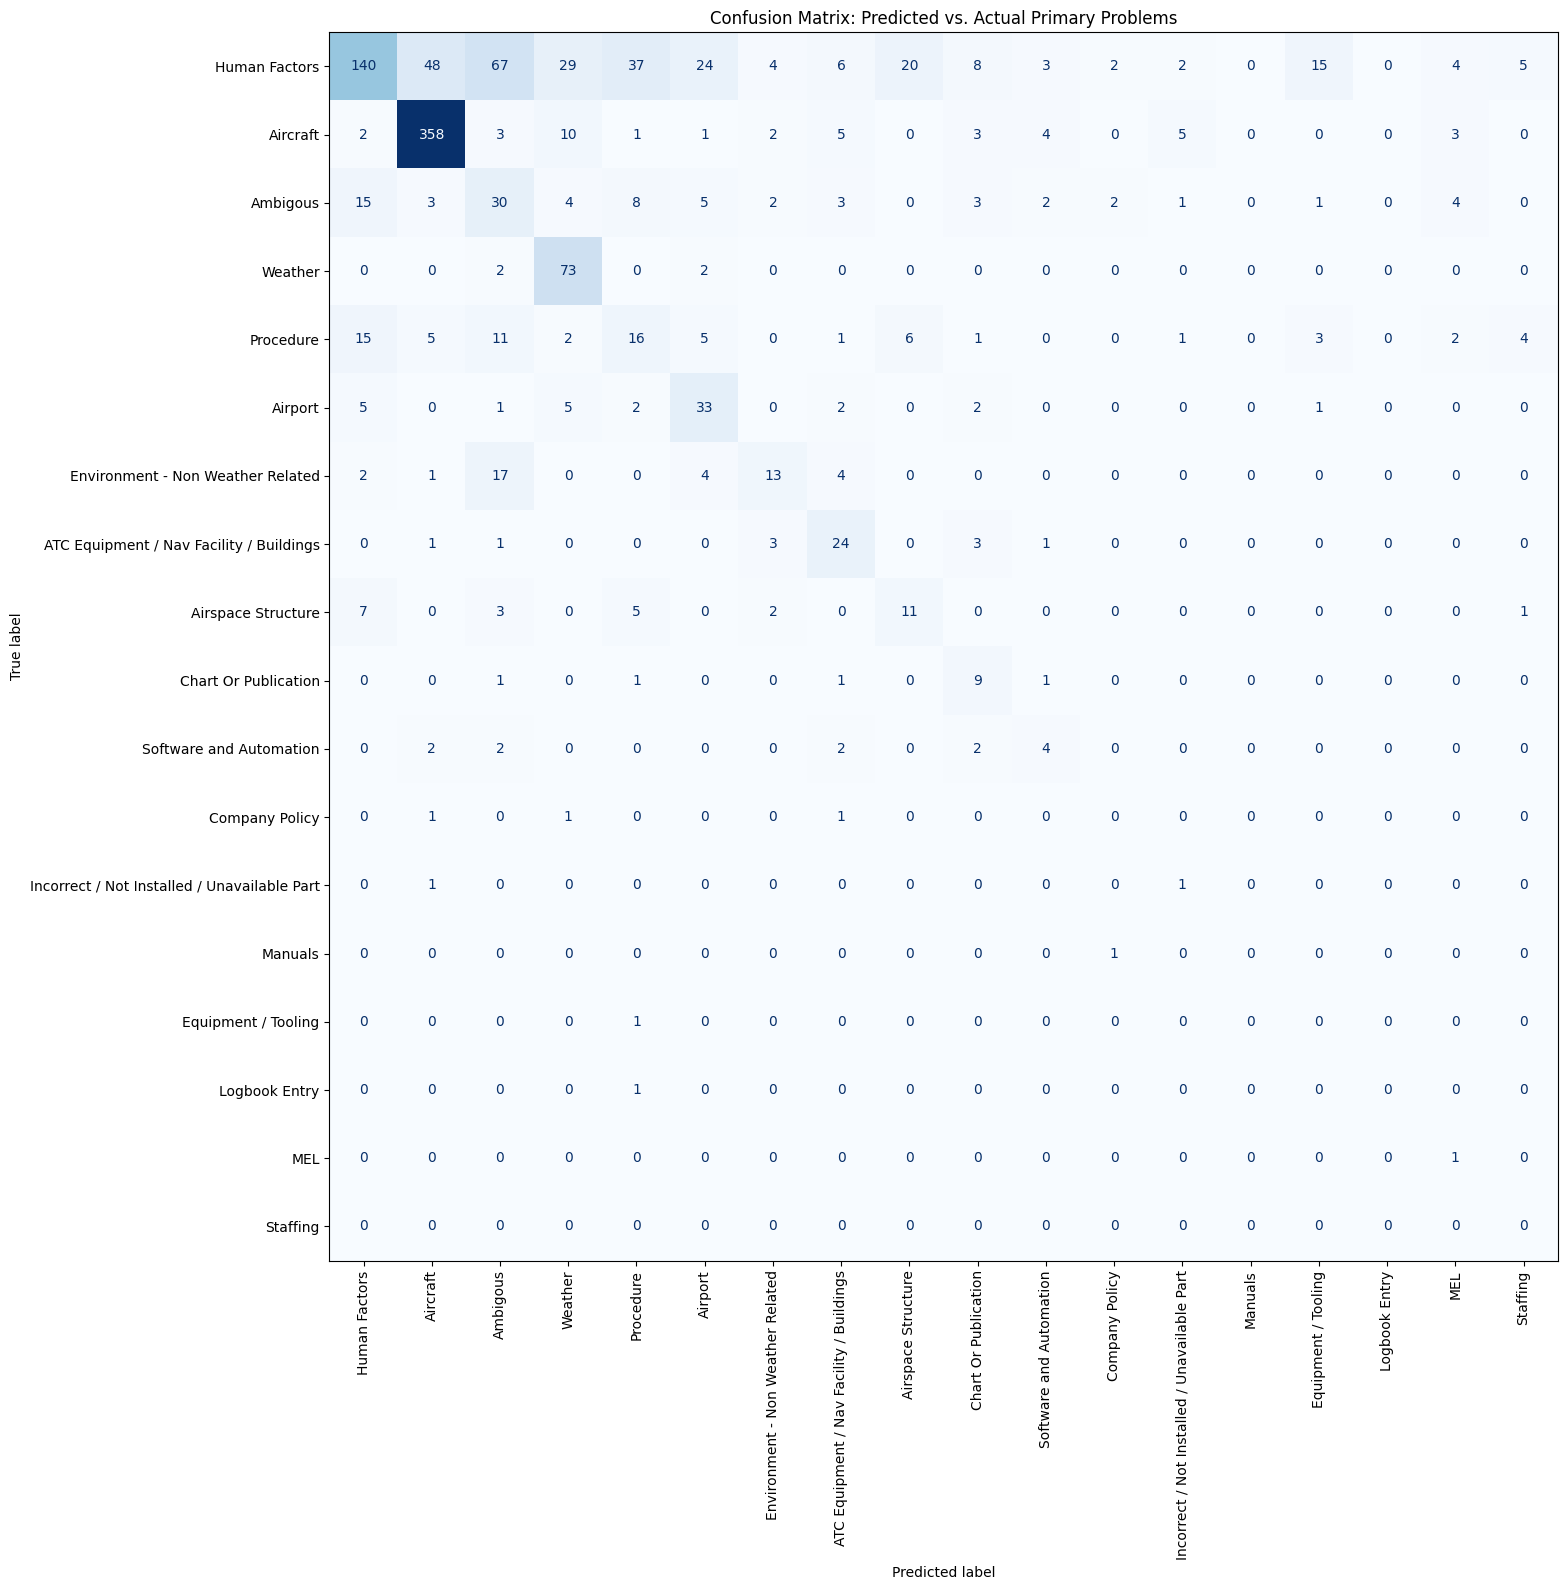

In [53]:
labels = list(label_mapping.values())

fig, ax = plt.subplots(figsize=(16, 16))
cm = confusion_matrix(test_df_2['Actual'], test_df_2['Predicted'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(xticks_rotation='vertical', ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: Predicted vs. Actual Primary Problems")
plt.tight_layout()
plt.show()

In [55]:
pipeline_preds = classifier(test_df_2['Narrative'].tolist(), batch_size=16, truncation=True)

test_df_2['Confidence'] = [pred['score'] for pred in pipeline_preds]

errors_df = test_df_2[test_df_2['Actual'] != test_df_2['Predicted']].copy()

confident_errors = errors_df.sort_values(by='Confidence', ascending=False)

print(f"Total misclassifications: {len(errors_df)} out of {len(test_df_2)}")
print("\nTop 5 Most Confident Mistakes:")
display(confident_errors[['Actual', 'Predicted', 'Confidence', 'Narrative']].head())

Total misclassifications: 518 out of 1231
\nTop 5 Most Confident Mistakes:


,Actual,Predicted,Confidence,Narrative
219,Ambigous,Weather,0.978609,i took off mco at xa:30 just after an airliner...
1121,Aircraft,Weather,0.975294,on vectors to final in zzz we were experiencin...
180,Human Factors,Weather,0.974756,after departing zzz during the climb phase the...
332,Human Factors,Weather,0.973146,during a manually flown level off at fl280; th...
964,Human Factors,Weather,0.960558,upon arrival into zzz after an uneventful flig...


In [64]:
top_3_errors = confident_errors.head(3)

for idx, row in top_3_errors.iterrows():
    print("="*80)
    print(f"ACTUAL: {row['Actual']} | PREDICTED: {row['Predicted']} (Confidence: {row['Confidence']:.2f})")

    inputs = tokenizer(row['Narrative'], return_tensors="pt", truncation=True, max_length=512)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    baseline_token_id = tokenizer.pad_token_id or 0
    ref_input_ids = torch.full_like(input_ids, baseline_token_id).to(device)

    pred_idx = list(label_mapping.keys())[list(label_mapping.values()).index(row['Predicted'])]

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=ref_input_ids,
        target=pred_idx,
        additional_forward_args=(attention_mask,),
        n_steps=50,
        return_convergence_delta=True
    )

    token_attributions = attributions.sum(dim=-1).squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    word_scores = list(zip(tokens, token_attributions.tolist()))
    word_scores.sort(key=lambda x: abs(x[1]), reverse=True)

    print("\nTop 5 highly influential tokens for this incorrect prediction:")
    for token, score in word_scores[:5]:
        if token not in ['[CLS]', '[SEP]', '[PAD]']:
            print(f"{token:<15} : {score:.4f}")
    print("\\n")

ACTUAL: Ambigous | PREDICTED: Weather (Confidence: 0.98)

Top 5 highly influential tokens for this incorrect prediction:
wind            : 0.7541
turbulence      : 0.6256
turbulence      : 0.3646
extreme         : 0.3144
\n
ACTUAL: Aircraft | PREDICTED: Weather (Confidence: 0.98)

Top 5 highly influential tokens for this incorrect prediction:
turbulence      : 1.5863
airplane        : 0.3926
##eng           : -0.3024
auto            : 0.2870
\n
ACTUAL: Human Factors | PREDICTED: Weather (Confidence: 0.97)

Top 5 highly influential tokens for this incorrect prediction:
severe          : 0.4056
mountain        : 0.2525
speed           : 0.2284
mountain        : 0.2114
\n
